<a href="https://colab.research.google.com/github/LexDomingues/Transfer-learning_and_Fine-tuning_cats_and_dogs/blob/main/Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline

import os

#if using Theano with GPU
#os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import load_img, img_to_array


import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

In [ ]:
!echo "Downloading cats_vs_dogs images"

# I created this folder because pulling the images directly from Drive was making the training take too long
!mkdir "/content/PetImages"

!cp -r "/content/drive/MyDrive/dataset/PetImages/Cat" "/content/PetImages/"
!cp -r "/content/drive/MyDrive/dataset/PetImages/Dog" "/content/PetImages/"
print(os.listdir("/content/PetImages"))
root = "/content/PetImages"
print(os.listdir(root))



mkdir: cannot create directory ‘/content/PetImages’: File exists
['Cat', 'Dog']
['Cat', 'Dog']


In [ ]:
# I added this because there were some corrupted and empty files that were interfering with my training

bad_files_tf = []

for category in ["Cat", "Dog"]:
  folder = f"/content/PetImages/{category}"

  for filename in os.listdir(folder):
      path = os.path.join(folder, filename)

      try:
          data = tf.io.read_file(path)
          image = tf.io.decode_image(
              data,
              channels=3,
              expand_animations=False
          )

          _ = image.numpy()

      except Exception as e:
          bad_files_tf.append((path, str(e)))

print("Problematic files:", len(bad_files_tf))

for path, error in bad_files_tf:
  print(path)
  print("Error:", error)

Problematic files: 11
/content/PetImages/Cat/666.jpg
Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input is empty. [Op:DecodeImage] name: 
/content/PetImages/Cat/4351.jpg
Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
/content/PetImages/Cat/Thumbs.db
Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, JPEG XL, PNG, GIF, BMP, WebP required. [Op:DecodeImage] name: 
/content/PetImages/Cat/10404.jpg
Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, JPEG XL, PNG, GIF, BMP, WebP required. [Op:DecodeImage] name: 
/content/PetImages/Dog/9500.jpg
Error: {{function_node __wrapped__DecodeImage_device_/job:localh

In [ ]:
# And this is to delete the corrupted files

bad_files = [
   "/content/PetImages/Cat/666.jpg",
   "/content/PetImages/Dog/11702.jpg",
   "/content/PetImages/Cat/4351.jpg",
   "/content/PetImages/Cat/Thumbs.db",
   "/content/PetImages/Cat/10404.jpg",
   "/content/PetImages/Dog/11912.jpg",
   "/content/PetImages/Dog/2317.jpg",
   "/content/PetImages/Dog/Thumbs.db",
   "/content/PetImages/Dog/11233.jpg",
   "/content/PetImages/Dog/2494.jpg",
   "/content/PetImages/Dog/9500.jpg",
   "/content/PetImages/Cat/2606.jpg",
   "/content/PetImages/Dog/9215.jpg",
]

for path in bad_files:
 if os.path.exists(path):
     os.remove(path)
     print("Removido:", path)

Removido: /content/PetImages/Cat/666.jpg
Removido: /content/PetImages/Dog/11702.jpg
Removido: /content/PetImages/Cat/4351.jpg
Removido: /content/PetImages/Cat/Thumbs.db
Removido: /content/PetImages/Cat/10404.jpg
Removido: /content/PetImages/Dog/11912.jpg
Removido: /content/PetImages/Dog/2317.jpg
Removido: /content/PetImages/Dog/Thumbs.db
Removido: /content/PetImages/Dog/11233.jpg
Removido: /content/PetImages/Dog/2494.jpg
Removido: /content/PetImages/Dog/9500.jpg
Removido: /content/PetImages/Cat/2606.jpg
Removido: /content/PetImages/Dog/9215.jpg


In [ ]:
train_split, val_split = 0.7, 0.15

categories = [x[0] for x in os.walk(root) if x[0]][1:]
categories = [c for c in categories if c not in [os.path.join(root)]]

print(categories)

['/content/PetImages/Cat', '/content/PetImages/Dog']


In [ ]:
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x

In [ ]:
#I did this because the code was exceeding the RAM limit; this way, it stays within the limit.
#This part of the code loads the images, separates the data, and specifies the number of classes.

train_ds = keras.utils.image_dataset_from_directory(
    root,
    validation_split=0.30,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

remaining_ds = keras.utils.image_dataset_from_directory(
    root,
    validation_split=0.30,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

total_batches = tf.data.experimental.cardinality(remaining_ds).numpy()
split = total_batches // 2

val_ds = remaining_ds.take(split)
test_ds = remaining_ds.skip(split)

Found 24989 files belonging to 2 classes.
Using 17493 files for training.
Found 24989 files belonging to 2 classes.
Using 7496 files for validation.


In [ ]:
num_classes = len(train_ds.class_names)
print("categories:", train_ds.class_names)
print("number of categories:", num_classes)

#gets the batches from within train_ds and val_ds
print("training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds).numpy())

for images, labels in train_ds.take(1):
    print("training batch shape:", images.shape)
    #This doesn't have a one-hot encoding.
    print("training labels shape:", labels.shape)

categories: ['Cat', 'Dog']
number of categories: 2
training batches: 547
validation batches: 117
test batches: 118
training batch shape: (32, 224, 224, 3)
training labels shape: (32,)


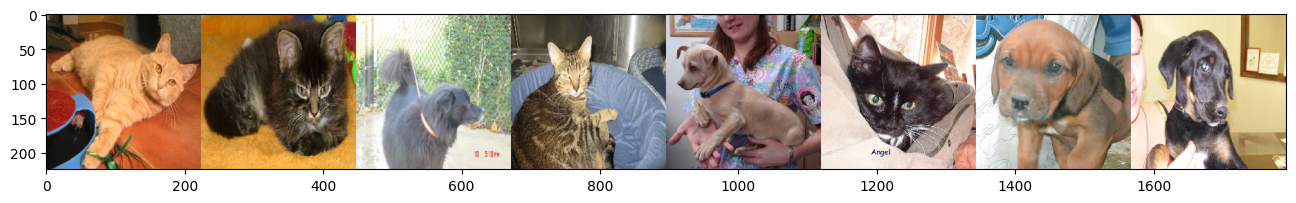

In [ ]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

In [ ]:
num_classes = len(train_ds.class_names)

base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
inputs = keras.Input(shape=(224, 224, 3))

x = keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_new = Model(inputs, outputs)

In [ ]:
model_new.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_new.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history2 = model_new.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)


Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 579s 1s/step - accuracy: 0.9817 - loss: 0.0534 - val_accuracy: 0.9888 - val_loss: 0.0347
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - accuracy: 0.9898 - loss: 0.0302 - val_accuracy: 0.9877 - val_loss: 0.0375
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 599s 1s/step - accuracy: 0.9919 - loss: 0.0245 - val_accuracy: 0.9890 - val_loss: 0.0346
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.9930 - loss: 0.0217 - val_accuracy: 0.9880 - val_loss: 0.0387
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.9947 - loss: 0.0190 - val_accuracy: 0.9888 - val_loss: 0.0369
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 621s 1s/step - accuracy: 0.9948 - loss: 0.0171 - val_accuracy: 0.9880 - val_loss: 0.0395
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 729s 1s/step - accuracy: 0.9955 - loss: 0.0149 - val_accuracy: 0.9885 - val_loss: 0.0393
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 597s 1s/step - accuracy: 0.9961 - loss: 0.0134 - val_accu

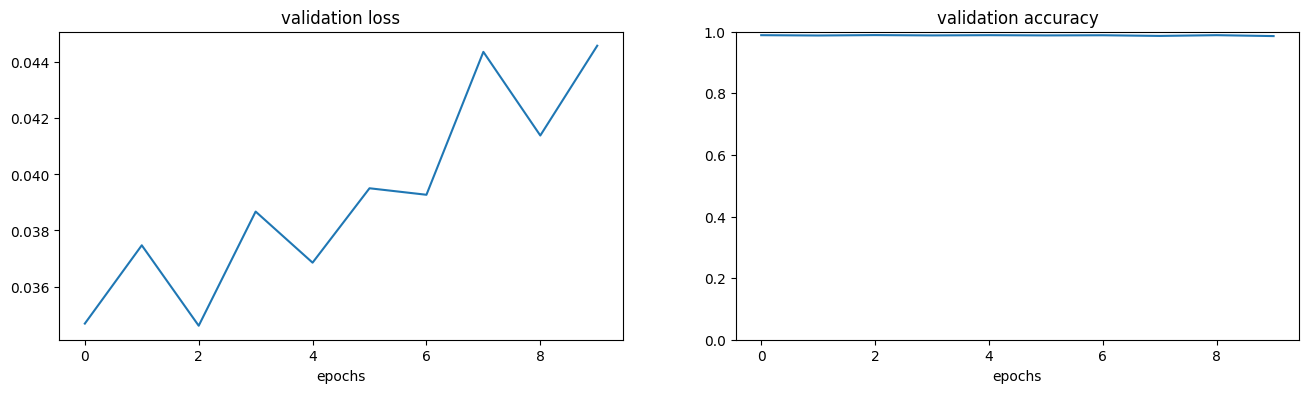

In [ ]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history2.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history2.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

In [ ]:
loss, accuracy = model_new.evaluate(test_ds)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

118/118 ━━━━━━━━━━━━━━━━━━━━ 101s 827ms/step - accuracy: 0.9896 - loss: 0.0361
Test loss: 0.036077190190553665
Test accuracy: 0.9896055459976196


In [ ]:
model_new.save("/content/drive/MyDrive/modelo_cats_dogs_transfer_learning.keras")

In [ ]:
model_new = keras.models.load_model(
    "/content/drive/MyDrive/modelo_cats_dogs_transfer_learning.keras"
)

#To find out which layer is MobileNetV2
for layer in model_new.layers:
    print(layer.name, type(layer))

input_layer_1 <class 'keras.src.layers.core.input_layer.InputLayer'>
mobilenetv2_1.00_224 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
dense <class 'keras.src.layers.core.dense.Dense'>


In [ ]:
base_model = model_new.get_layer("mobilenetv2_1.00_224")

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
model_new.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_finetune = model_new.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 731s 1s/step - accuracy: 0.9730 - loss: 0.0756 - val_accuracy: 0.9829 - val_loss: 0.0684
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 720s 1s/step - accuracy: 0.9853 - loss: 0.0403 - val_accuracy: 0.9842 - val_loss: 0.0546
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 717s 1s/step - accuracy: 0.9891 - loss: 0.0271 - val_accuracy: 0.9853 - val_loss: 0.0511
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 671s 1s/step - accuracy: 0.9902 - loss: 0.0262 - val_accuracy: 0.9858 - val_loss: 0.0482
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 696s 1s/step - accuracy: 0.9950 - loss: 0.0152 - val_accuracy: 0.9866 - val_loss: 0.0457


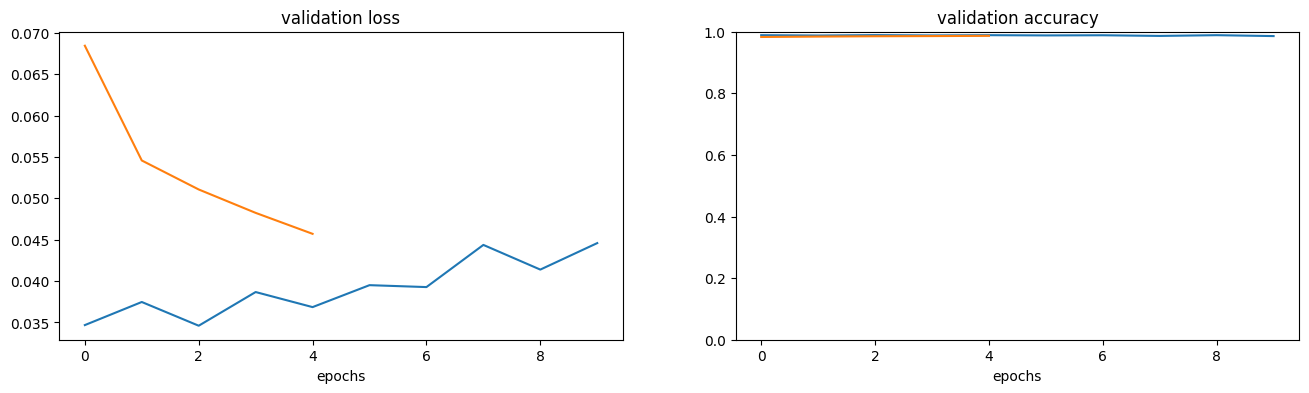

In [ ]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history2.history["val_loss"])
ax.plot(history_finetune.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history2.history["val_accuracy"])
ax2.plot(history_finetune.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

In [ ]:
loss, accuracy = model_new.evaluate(test_ds)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

In [ ]:
path = "images.jpg"

img = load_img(path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

probabilities = model_new.predict(x)

print(probabilities)